In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from bidict import bidict
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

In [2]:
ENCODER = bidict({
    'ha': 0,
    'pa': 1, 
    'ka' : 2,
    'sa': 3,
    'la': 4,
    'ta': 5,
    'na': 6,
})

In [3]:
labels = np.load("../data-cons1/labels.npy")
labels = labels - 1
labels.shape

(1047,)

In [4]:
imgs = np.load("../data-cons1/imgs.npy").astype("float32") / 255

In [5]:
# check out one of the images
# plt.figure()
# plt.imshow(imgs[0])
# plt.grid(False)
# plt.show()

In [6]:
if imgs.ndim == 3:
    imgs = np.expand_dims(imgs, -1)

In [7]:
imgs_train, imgs_test, labels_train, labels_test = train_test_split(
    imgs, labels, test_size=0.10, stratify=labels, random_state=42
)

In [8]:
print(imgs_train.shape)
print(labels_train.shape)

print(labels_train.min())
print(labels_train.max())

(942, 50, 50, 1)
(942,)
0
6


In [9]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1
)
datagen.fit(imgs_train)

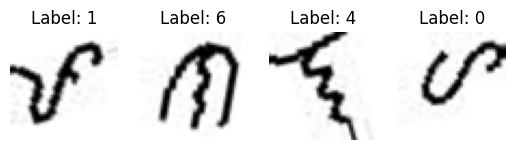

In [10]:
for x_batch, y_batch in datagen.flow(imgs_train, labels_train, batch_size=4):
    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.imshow(x_batch[i].squeeze(), cmap='gray')
        plt.title(f"Label: {y_batch[i]}")
        plt.axis('off')
    plt.show()
    break

In [11]:
batch_size = 8
epochs = 30

model = keras.Sequential([
    keras.Input(shape=(50, 50, 1)),

    # 1st Conv block
    layers.Conv2D(32, kernel_size=3, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.2),
    layers.BatchNormalization(),

    # 2nd Conv block
    layers.Conv2D(64, kernel_size=3, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.2),
    layers.BatchNormalization(),

    # 3rd Conv block
    layers.Conv2D(128, kernel_size=3, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.3),
    layers.BatchNormalization(),

    # Dense output block
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(7, activation="softmax")
])


In [12]:
np.unique(labels_train)

array([0, 1, 2, 3, 4, 5, 6], dtype=int64)

In [13]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True)

optimizer = keras.optimizers.Adam()

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
print("Labels train:", np.unique(labels_train, return_counts=True))
print("Labels test:", np.unique(labels_test, return_counts=True))

Labels train: (array([0, 1, 2, 3, 4, 5, 6], dtype=int64), array([131, 174, 109, 147, 124, 136, 121], dtype=int64))
Labels test: (array([0, 1, 2, 3, 4, 5, 6], dtype=int64), array([15, 19, 12, 16, 14, 15, 14], dtype=int64))


In [15]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_train),
    y=labels_train
)

class_weight_dict = dict(enumerate(class_weights))

model.fit(
    datagen.flow(imgs_train, labels_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(imgs_test, labels_test),
    callbacks=[early_stopping, lr_scheduler],
    class_weight=class_weight_dict
)

Epoch 1/30
118/118 [==============================] - 4s 25ms/step - loss: 2.0947 - accuracy: 0.4013 - val_loss: 2.6767 - val_accuracy: 0.1429 - lr: 0.0010
Epoch 2/30
118/118 [==============================] - 3s 23ms/step - loss: 1.0060 - accuracy: 0.7187 - val_loss: 3.6845 - val_accuracy: 0.1429 - lr: 0.0010
Epoch 3/30
117/118 [============================>.] - ETA: 0s - loss: 0.8174 - accuracy: 0.7655
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
118/118 [==============================] - 3s 22ms/step - loss: 0.8171 - accuracy: 0.7654 - val_loss: 4.8244 - val_accuracy: 0.1429 - lr: 0.0010
Epoch 4/30
118/118 [==============================] - 3s 22ms/step - loss: 0.6270 - accuracy: 0.8079 - val_loss: 6.0709 - val_accuracy: 0.1429 - lr: 5.0000e-04
Epoch 5/30
118/118 [==============================] - ETA: 0s - loss: 0.5692 - accuracy: 0.8408
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
118/118 [==============================

32 128-3-2 256-3-2 .9102
32 256-3-2 128-3-2 .9077
32 128-3-2 256-3-2 512-3-2 .9127
32 128-1-2 256-3-2 512-5-2 .9327
32 128-5-2 256-5-2 512-5-2 .9626

In [16]:
model.evaluate(imgs_test, labels_test)

4/4 [==============================] - 0s 14ms/step - loss: 2.6767 - accuracy: 0.1429


[2.6767430305480957, 0.1428571492433548]

In [ ]:
model.predict(imgs_test[:1])

In [ ]:
import numpy as np

sample_imgs = imgs_test[:5]
sample_labels = labels_test[:5]

preds = model.predict(sample_imgs)
predicted_classes = np.argmax(preds, axis=1)

print("Predicted:", predicted_classes)
print("Actual:   ", sample_labels)

In [ ]:
import numpy as np
from collections import Counter

print("Train:", Counter(labels_train))
print("Test:", Counter(labels_test))

In [ ]:
y_pred = model.predict(imgs_test).argmax(axis=1)
cm = confusion_matrix(labels_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Predict on test set
preds = model.predict(imgs_test)
pred_labels = np.argmax(preds, axis=1)

# Number of samples to show
num_samples = 10

# Inverse mapping from label to character
inv_encoder = {v: k for k, v in ENCODER.items()}

plt.figure(figsize=(15, 5))

for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(imgs_test[i].squeeze(), cmap='gray')
    plt.axis('off')
    
    actual = inv_encoder[labels_test[i]]
    predicted = inv_encoder[pred_labels[i]]
    
    color = 'green' if actual == predicted else 'red'
    plt.title(f"Pred: {predicted}\nTrue: {actual}", color=color)

plt.tight_layout()
plt.show()

In [ ]:
misclassified = np.where(y_pred != labels_test)[0]
for i in misclassified[:5]:  # show first 5 [:x}
    plt.imshow(imgs_test[i].squeeze(), cmap='gray') 
    
    true_char = ENCODER.inverse[labels_test[i] + 1]
    pred_char = ENCODER.inverse[y_pred[i] + 1]
    
    plt.title(f"True: {true_char}, Pred: {pred_char}")
    plt.axis('off')
    plt.show()

In [ ]:
model.summary()

In [ ]:
unique, counts = np.unique(labels_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Label {u}: {c} samples")

In [ ]:
model.save("baybayin_model_v4.keras")

In [ ]:
print(f"Num classes: {len(np.unique(labels))}")
print(f"Min label: {np.min(labels)}, Max label: {np.max(labels)}")

In [ ]:
import collections
print(collections.Counter(labels_train))

In [ ]:
for i in range(10):
    sample = imgs_test[i].reshape(1, 50, 50, 1)
    pred = np.argmax(model.predict(sample), axis=-1)[0]
    true = labels_test[i]
    print(f"True: {true}, Pred: {pred}")

In [ ]:
print(img_array.shape)